# Phase 1: Load & Explore Data

In [1]:
# Import the tool we need to load .mat files
import scipy.io

In [2]:
# Step 1: Load EMG_S.mat

# This is the path to our data file
file_path = "../data/raw/EMG_S.mat"

# loadmat() reads the .mat file and gives us back a Python dictionary
data = scipy.io.loadmat(file_path)

print("File loaded successfully!")

File loaded successfully!


In [3]:
# Step 2: Print the shape and keys of the data

# A .mat file loaded by scipy is a dictionary, so it has "keys"
# Each key is the name of a variable that was saved in the original .mat file
print("Keys in the data:")
print(data.keys())

Keys in the data:
dict_keys(['__header__', '__version__', '__globals__', 'matriz_ventanas'])


In [4]:
# Now let's check the shape of each variable
# We loop through every key in the dictionary
for key in data.keys():
    value = data[key]

    # Some keys are metadata added by scipy (like "__header__")
    # These start with double underscores, so we skip them
    if key.startswith("__"):
        continue

    print("Key:", key)
    print("Shape:", value.shape)
    print("Data type:", value.dtype)
    print("---")

Key: matriz_ventanas
Shape: (174000, 3, 200)
Data type: float64
---


In [5]:
# Step 3: Print what's inside (variables, dimensions)

# Let's look at the scipy metadata keys too, just to see what they contain
print("Header info:", data["__header__"])
print("Version:", data["__version__"])
print("Globals:", data["__globals__"])

Header info: b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Sat Nov 23 10:47:34 2024'
Version: 1.0
Globals: []


In [6]:
# Step 4: Show the first few samples

# We loop through the real data keys again (skipping the __ metadata ones)
# and print a small preview of each variable
for key in data.keys():
    if key.startswith("__"):
        continue

    value = data[key]

    print("Key:", key)
    print("First few values:")
    print(value[:5])
    print("===")

Key: matriz_ventanas
First few values:
[[[-0.04006155 -0.00232896 -0.02167901 ... -0.02232401 -0.00136146
   -0.01619649]
  [-0.00458646 -0.00136146 -0.02716152 ...  0.04120865  0.25180167
    0.27760173]
  [-0.02425901  0.11248133  0.08668126 ...  0.24115914  0.19084902
   -0.10681922]]

 [[-0.0613466  -0.07102163 -0.1000467  ... -0.02812902 -0.02619402
   -0.02329151]
  [ 0.10603131  0.01798859 -0.1019817  ...  0.11635134  0.35983944
    0.13441138]
  [ 0.18633401  0.01669859 -0.04264156 ... -0.12842677  0.09151877
   -0.16132185]]

 [[ 0.00444356 -0.03490154  0.00379856 ... -0.11681674  0.00379856
   -0.03715904]
  [ 0.12441386  0.01863359 -0.12326676 ... -0.00458646 -0.03328903
    0.09764629]
  [ 0.00928107 -0.01684149 -0.19034692 ... -0.00781147  0.0618487
   -0.00974648]]

 [[-0.08263166 -0.01135898 -0.08972667 ...  0.03669364 -0.02845152
   -0.02200151]
  [-0.15035682 -0.16067685 -0.04070655 ... -0.0187765  -0.18776692
   -0.22904702]
  [-0.16164435  0.20826406  0.28695426 ... 

In [7]:
import sys
print("Python path:", sys.executable)

try:
    import numpy
    print("numpy: OK, version", numpy.__version__)
except ImportError:
    print("numpy: NOT FOUND")

try:
    import scipy
    print("scipy: OK, version", scipy.__version__)
except ImportError:
    print("scipy: NOT FOUND")

try:
    import pandas
    print("pandas: OK, version", pandas.__version__)
except ImportError:
    print("pandas: NOT FOUND")

Python path: /home/via/IPBR/emg-gesture-classification/venv/bin/python
numpy: OK, version 2.5.1
scipy: OK, version 1.18.0


pandas: OK, version 3.0.3


In [8]:
# Extract the pre-windowed EMG data from the loaded .mat dictionary
matriz_ventanas = data['matriz_ventanas']

print("Extracted matriz_ventanas, shape:", matriz_ventanas.shape)

Extracted matriz_ventanas, shape: (174000, 3, 200)


# Phase 2: Load Gesture Labels

In [9]:
# Step 1: Load Labels.mat
# This file holds the gesture label for each window in matriz_ventanas

labels_path = "../data/raw/Labels.mat"
labels_data = scipy.io.loadmat(labels_path)

# 1. Print the keys in the file
print("Keys in Labels.mat:")
print(labels_data.keys())
print()

# 2. Print the shape of each array (skip the scipy metadata keys)
for key in labels_data.keys():
    if key.startswith("__"):
        continue

    value = labels_data[key]
    print("Key:", key)
    print("Shape:", value.shape)
    print("Data type:", value.dtype)
    print("---")
print()

# 3. Print the first 20 values of each array
for key in labels_data.keys():
    if key.startswith("__"):
        continue

    value = labels_data[key]
    print("Key:", key)
    print("First 20 values:")
    print(value[:20])
    print("===")

Keys in Labels.mat:


dict_keys(['__header__', '__version__', '__globals__', 'labels'])

Key: labels
Shape: (174000, 5)
Data type: uint8
---

Key: labels
First 20 values:
[[1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]]
===


In [10]:
# Step 2: Verify the gesture label mapping

labels = labels_data["labels"]

# 1. Sum each column to count how many samples belong to each gesture.
#    Since labels are one-hot, summing down a column counts the 1s in it.
counts_per_column = labels.sum(axis=0)

print("Sample count per column:")
for col_index, count in enumerate(counts_per_column):
    print(f"Column {col_index}: {count} samples")
print()

# 2. Print the first 10 rows so we can see the one-hot pattern directly
print("First 10 rows of labels:")
print(labels[:10])

Sample count per column:
Column 0: 34800 samples
Column 1: 34800 samples
Column 2: 34800 samples
Column 3: 34800 samples
Column 4: 34800 samples

First 10 rows of labels:
[[1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]]


**Assumed gesture order** (per DS1 documentation — not yet verified against the raw source):

- Column 0 = Gesture 1 (fist)
- Column 1 = Gesture 2 (thumb bend)
- Column 2 = Gesture 3 (rest)
- Column 3 = Gesture 4 (finger extension)
- Column 4 = Gesture 5 (middle/ring bend)

# Phase 3: Visualize Raw Signals

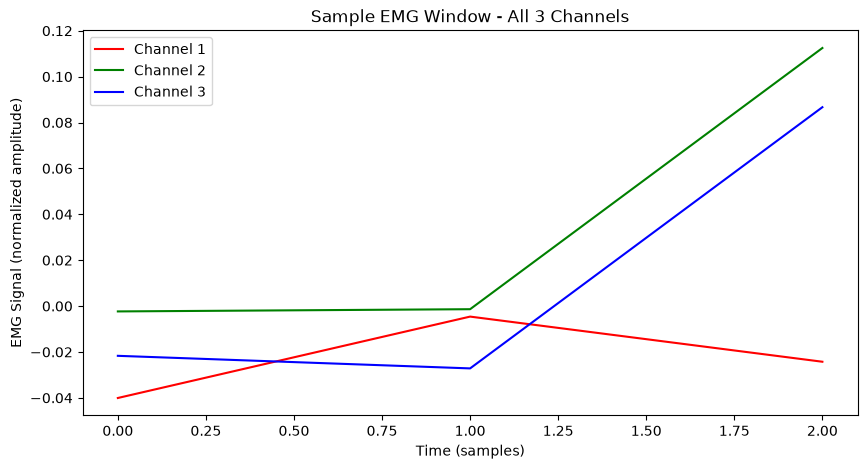

In [11]:
# Import the plotting tool we need
import matplotlib.pyplot as plt

# Step 1: Grab the first window from our windows matrix
# matriz_ventanas holds many windows, so [0] picks the very first one
first_window = matriz_ventanas[0]

# This window has 3 channels, one for each EMG sensor
# We pull each channel out as its own column of numbers
channel_1 = first_window[:, 0]
channel_2 = first_window[:, 1]
channel_3 = first_window[:, 2]

# Step 2: Create the plot and draw each channel in a different color
plt.figure(figsize=(10, 5))
plt.plot(channel_1, color="red", label="Channel 1")
plt.plot(channel_2, color="green", label="Channel 2")
plt.plot(channel_3, color="blue", label="Channel 3")

# Step 3: Label the axes
plt.xlabel("Time (samples)")
plt.ylabel("EMG Signal (normalized amplitude)")

# Step 4: Add a title
plt.title("Sample EMG Window - All 3 Channels")

# Show the legend so we know which color is which channel
plt.legend()

# Save a copy of this plot to the visualizations folder
plt.savefig('../visualizations/phase3_single_window.png', dpi=150, bbox_inches='tight')

# Display the plot
plt.show()

# Phase 4: Compare Signals Across Gestures

First window index for each gesture: [np.int64(0), np.int64(34800), np.int64(69600), np.int64(104400), np.int64(139200)]


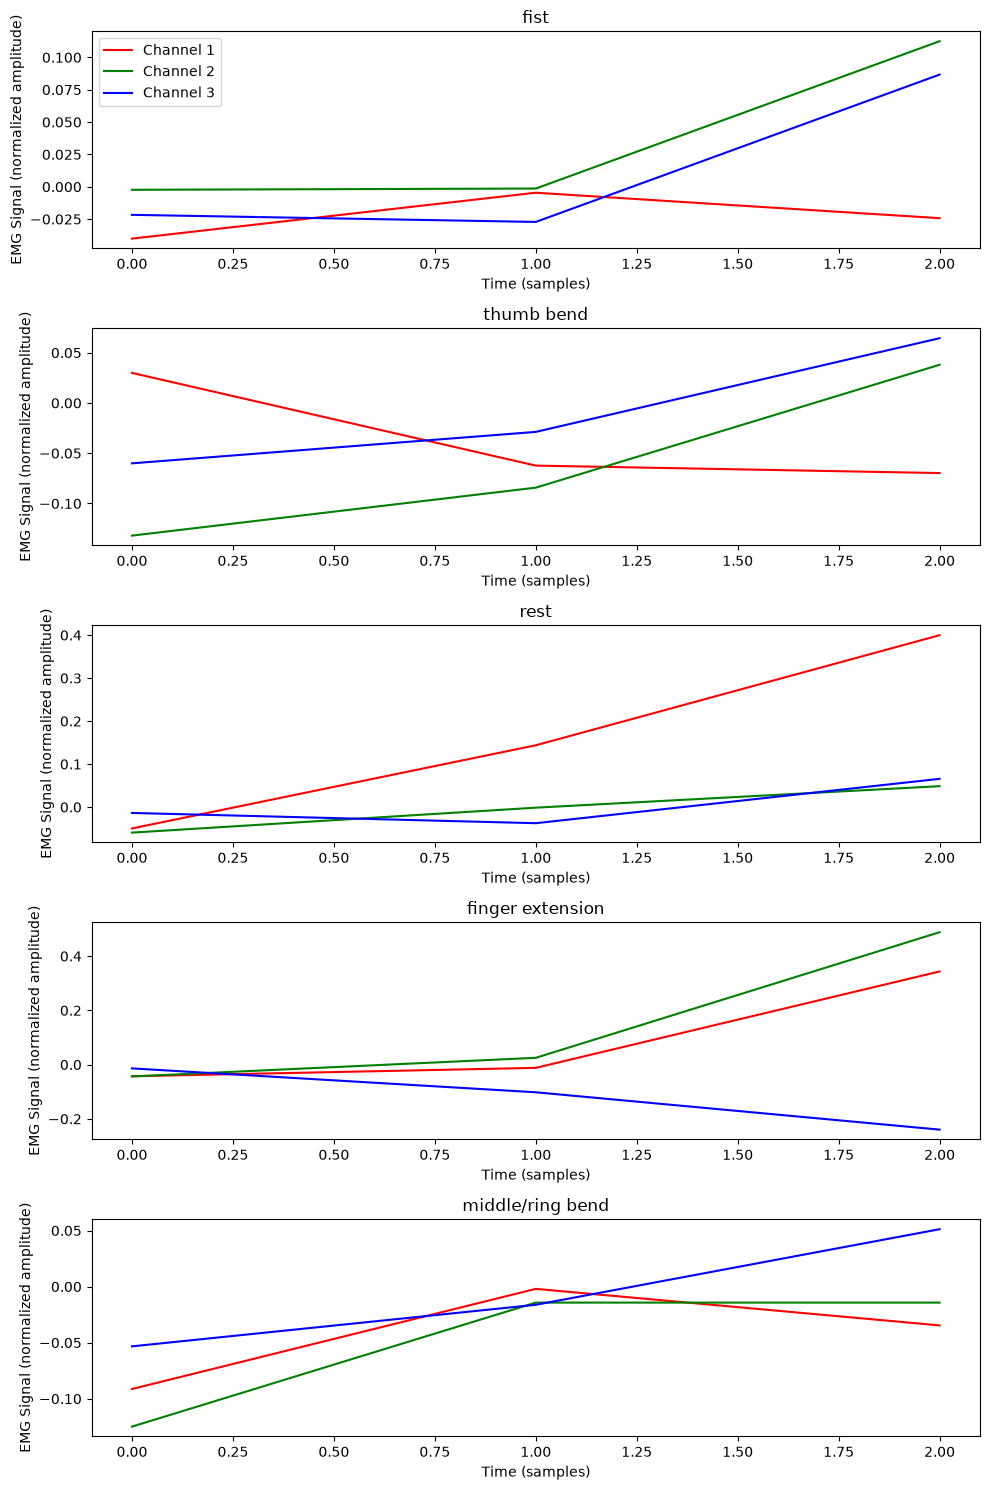

In [12]:
# Step 1: Names of the 5 gestures, in the same column order as labels
gesture_names = [
    "fist",
    "thumb bend",
    "rest",
    "finger extension",
    "middle/ring bend",
]

# We need numpy's "where" function to search the labels array
import numpy as np

# Step 2: For each gesture, find the index of its first window
# labels[:, gesture_index] is a column of 0s and 1s for that gesture
# np.where(...)[0] gives us all row indices where that column is 1
# [0] at the end picks just the first one
first_index_per_gesture = []

for gesture_index in range(5):
    matching_rows = np.where(labels[:, gesture_index] == 1)[0]
    first_index = matching_rows[0]
    first_index_per_gesture.append(first_index)

print("First window index for each gesture:", first_index_per_gesture)

# Step 3: Create a figure with 5 subplots, stacked vertically
fig, axes = plt.subplots(5, 1, figsize=(10, 15))

# Step 4: Plot each gesture's example window in its own subplot
for gesture_index in range(5):
    window_index = first_index_per_gesture[gesture_index]
    example_window = matriz_ventanas[window_index]

    channel_1 = example_window[:, 0]
    channel_2 = example_window[:, 1]
    channel_3 = example_window[:, 2]

    ax = axes[gesture_index]
    ax.plot(channel_1, color="red", label="Channel 1")
    ax.plot(channel_2, color="green", label="Channel 2")
    ax.plot(channel_3, color="blue", label="Channel 3")

    ax.set_title(gesture_names[gesture_index])
    ax.set_xlabel("Time (samples)")
    ax.set_ylabel("EMG Signal (normalized amplitude)")

# Step 5: Add a legend only to the top subplot, to avoid clutter
axes[0].legend()

# Step 6: Tidy up spacing between subplots and display the figure
plt.tight_layout()

# Save a copy of this plot to the visualizations folder
plt.savefig('../visualizations/phase4_gesture_comparison.png', dpi=150, bbox_inches='tight')

plt.show()

# Phase 5: Basic Data Cleaning

In [13]:
# Step 1: Check for NaN or missing values in matriz_ventanas
nan_count = np.isnan(matriz_ventanas).sum()
print("Number of NaN values in matriz_ventanas:", nan_count)

# Step 2: Check for completely flat/zero windows
# A window is "flat" if every value in it is exactly 0
# matriz_ventanas has shape (174000, 3, 200), so axis 1 and 2 are
# the channel and time axes within a single window
flat_window_mask = np.all(matriz_ventanas == 0, axis=(1, 2))
flat_window_count = flat_window_mask.sum()
print("Number of completely flat/zero windows:", flat_window_count)

# Step 3: Compute basic statistics across the whole dataset
print()
print("Basic statistics for matriz_ventanas:")
print("Min:", matriz_ventanas.min())
print("Max:", matriz_ventanas.max())
print("Mean:", matriz_ventanas.mean())
print("Std:", matriz_ventanas.std())

# Step 4: Find which windows contain a NaN anywhere inside them
nan_window_mask = np.isnan(matriz_ventanas).any(axis=(1, 2))

# A window is "bad" if it has a NaN, OR it is completely flat
bad_window_mask = nan_window_mask | flat_window_mask
bad_window_count = bad_window_mask.sum()

# Step 5: If any bad windows were found, remove them from both
# matriz_ventanas and labels so the two arrays stay aligned
print()
if bad_window_count > 0:
    good_window_mask = ~bad_window_mask

    matriz_ventanas = matriz_ventanas[good_window_mask]
    labels = labels[good_window_mask]

    print("Removed", bad_window_count, "bad window(s).")
    print("Windows remaining:", matriz_ventanas.shape[0])
else:
    print("No NaN values or flat windows found. Data is clean as-is.")

Number of NaN values in matriz_ventanas: 0
Number of completely flat/zero windows: 0

Basic statistics for matriz_ventanas:
Min: -5.04559641747619


Max: 4.002808437100612
Mean: -0.009554945120255722


Std: 0.15977089049272003

No NaN values or flat windows found. Data is clean as-is.
